Comparing with vanilla NPE

In [4]:
import torch
from sbi.inference import NPE
from sbi.utils import BoxUniform
from sbi.analysis import pairplot
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import IterableDataset, DataLoader
import lampe
import corner

/home/oestequeda/Desktop/Workstation/PFN_pewpew_analytics/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# ==========================================
# 1. CONSTANTS & SETUP
# ==========================================
SENSOR_FS = 0.26
RECORD_DURATION = 100.0
num_samples = int(SENSOR_FS * RECORD_DURATION)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Simulator

In [6]:
# ==========================================
# 2. SIMULATOR & DATASET
# ==========================================
def thermal_simulator_abc(theta, fs=0.26, duration=100.0):
    """5-Parameter Physics Model"""
    k, T_env, t_0, T_initial, sigma = theta[0], theta[1], theta[2], theta[3], theta[4]
    
    num_steps = int(fs * duration)
    # FIX: Tell 't' to live on the same device as 'theta'
    t = torch.linspace(0.0, duration, steps=num_steps, device=theta.device)
    
    clean_curve = T_env + (T_initial - T_env) * torch.exp(-k * (t - t_0))
    noise = torch.randn_like(clean_curve) * sigma
    return clean_curve + noise

class DynamicThermalDatasetABC(IterableDataset):
    def __init__(self, batch_size=256, fs=0.26, duration=100.0, sigma_bounds=(0.1, 5.0)):
        super().__init__()
        self.batch_size = batch_size
        self.fs = fs
        self.duration = duration
        
        self.lower_bounds = torch.tensor([0.001, 290.0, -5.0, 300.0, sigma_bounds[0]])
        self.upper_bounds = torch.tensor([0.1,   315.0,  5.0, 400.0, sigma_bounds[1]])
        
    def __iter__(self):
        while True:
            u = torch.rand((self.batch_size, 5))
            theta_batch = self.lower_bounds + u * (self.upper_bounds - self.lower_bounds)
            
            x_list = [
                thermal_simulator_abc(t, self.fs, self.duration) 
                for t in theta_batch
            ]
            x_batch = torch.stack(x_list)
            yield theta_batch, x_batch

In [7]:
# ==========================================
# 3. NORMALIZER UTILITIES
# ==========================================
class ThetaNormalizer:
    def __init__(self, lower_bounds, upper_bounds, device):
        self.low = lower_bounds.to(device)
        self.high = upper_bounds.to(device)

    def normalize(self, theta):
        return 2.0 * (theta - self.low) / (self.high - self.low) - 1.0

    def unnormalize(self, theta_norm):
        return self.low + (theta_norm + 1.0) / 2.0 * (self.high - self.low)

class XNormalizer:
    def __init__(self, dataset, device, num_samples=5000):
        print("Calculating dataset statistics for x normalization...")
        loader = DataLoader(dataset, batch_size=num_samples)
        _, x_dummy = next(iter(loader))
        self.mean = x_dummy.mean().to(device)
        self.std = x_dummy.std().to(device)

    def normalize(self, x):
        return (x - self.mean) / self.std

Initializing

In [8]:
# ==========================================
# 4. INITIALIZATION
# ==========================================
dataset = DynamicThermalDatasetABC(
    batch_size=256, fs=SENSOR_FS, duration=RECORD_DURATION, sigma_bounds=(0.1, 5.0)
)
dataloader = DataLoader(dataset, batch_size=None)
data_iter = iter(dataloader)

# Initialize normalizers
theta_norm_layer = ThetaNormalizer(dataset.lower_bounds, dataset.upper_bounds, device)
x_norm_layer = XNormalizer(dataset, device)

# Initialize Custom Architecture (Neural Spline Flow, 3 layers of 128)
estimator = lampe.inference.NPE(
    theta_dim=5, 
    x_dim=num_samples,
    build=zuko.flows.NSF,            
    transforms=3,                    
    hidden_features=[64, 64]  
).to(device)

epochs = 50
steps_per_epoch = 100

optimizer = torch.optim.Adam(estimator.parameters(), lr=1e-3)
# Cosine Annealing Scheduler for better convergence
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * steps_per_epoch, eta_min=1e-5)

Calculating dataset statistics for x normalization...


Training loop

In [9]:
# ==========================================
# 5. TRAINING LOOP
# ==========================================
print(f"Starting NPE training on {device}...")
estimator.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        theta_train, x_train = next(data_iter)
        theta_train, x_train = theta_train.to(device), x_train.to(device)
        
        # NORMALIZE BEFORE NETWORK
        theta_norm = theta_norm_layer.normalize(theta_train)
        x_norm = x_norm_layer.normalize(x_train)
        
        optimizer.zero_grad()
        loss = -estimator(theta_norm, x_norm).mean()
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(estimator.parameters(), 1.0)
        optimizer.step()
        scheduler.step() # Step the learning rate scheduler
        
        epoch_loss += loss.item()
        
    print(f"Epoch {epoch+1:03d} | Loss: {epoch_loss / steps_per_epoch:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")


Starting NPE training on cuda...
Epoch 001 | Loss: 1.7449 | LR: 9.99e-04
Epoch 002 | Loss: -0.4019 | LR: 9.96e-04
Epoch 003 | Loss: -1.2971 | LR: 9.91e-04
Epoch 004 | Loss: -1.7310 | LR: 9.84e-04
Epoch 005 | Loss: -1.8547 | LR: 9.76e-04
Epoch 006 | Loss: -2.2494 | LR: 9.65e-04
Epoch 007 | Loss: -2.5157 | LR: 9.53e-04
Epoch 008 | Loss: -2.6410 | LR: 9.39e-04
Epoch 009 | Loss: -2.7952 | LR: 9.23e-04
Epoch 010 | Loss: -2.8457 | LR: 9.05e-04
Epoch 011 | Loss: -2.9360 | LR: 8.86e-04
Epoch 012 | Loss: -3.1464 | LR: 8.66e-04
Epoch 013 | Loss: -3.2456 | LR: 8.44e-04
Epoch 014 | Loss: -3.3004 | LR: 8.21e-04
Epoch 015 | Loss: -3.3717 | LR: 7.96e-04
Epoch 016 | Loss: -3.3839 | LR: 7.70e-04
Epoch 017 | Loss: -3.3784 | LR: 7.43e-04
Epoch 018 | Loss: -3.5342 | LR: 7.16e-04
Epoch 019 | Loss: -3.6184 | LR: 6.87e-04
Epoch 020 | Loss: -3.6554 | LR: 6.58e-04
Epoch 021 | Loss: -3.7195 | LR: 6.28e-04
Epoch 022 | Loss: -3.7596 | LR: 5.98e-04
Epoch 023 | Loss: -3.7908 | LR: 5.67e-04
Epoch 024 | Loss: -3.7947

Testing

Generating posterior predictive corner plot...


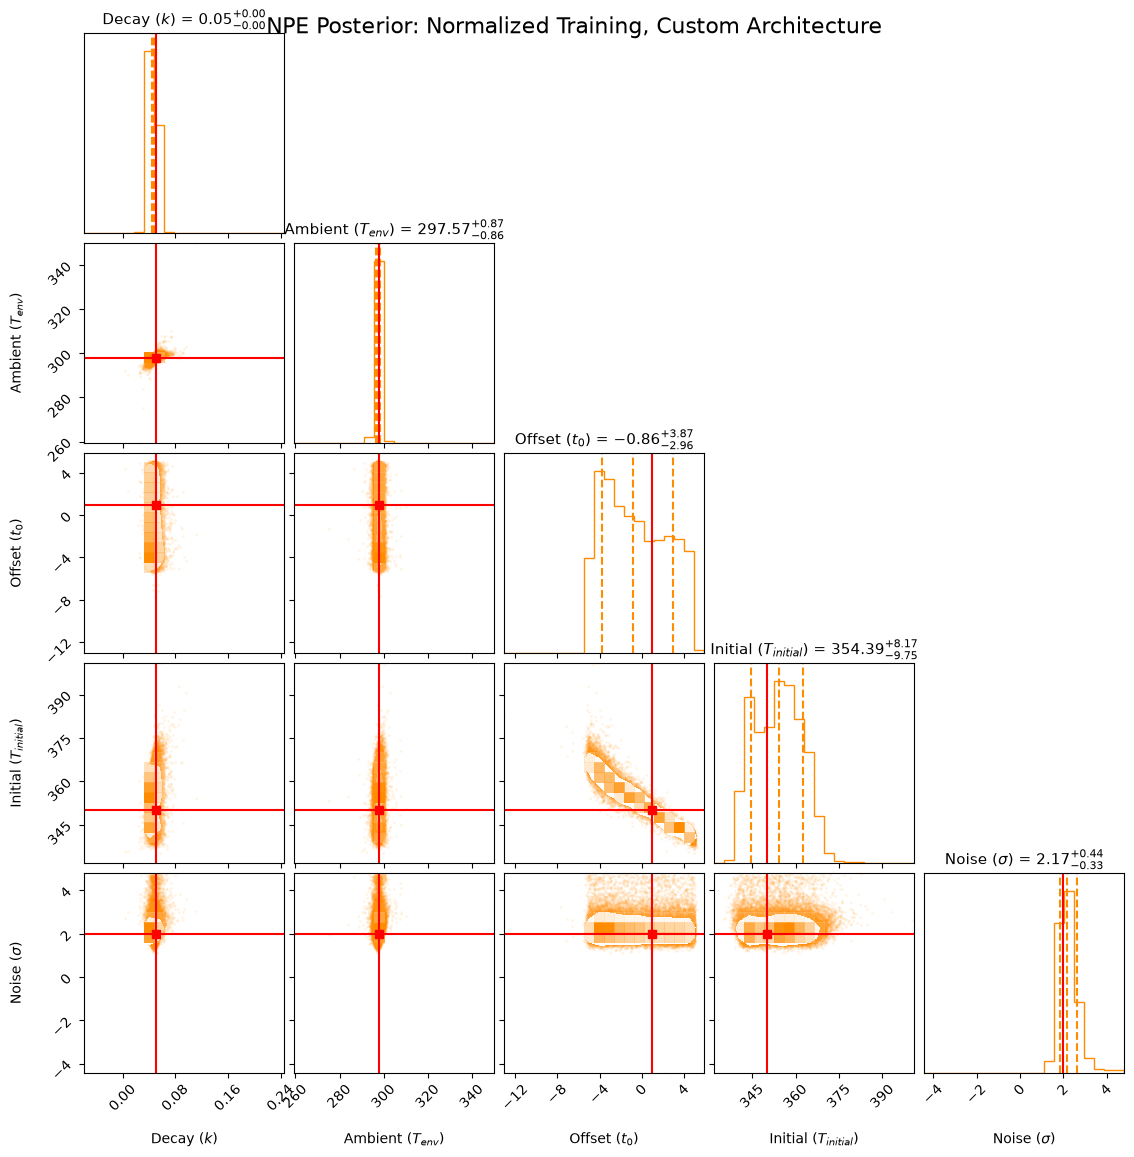

In [11]:
# ==========================================
# 6. INFERENCE & PLOTTING
# ==========================================
print("Generating posterior predictive corner plot...")
estimator.eval()

with torch.no_grad():
    # True values
    true_theta_tensor = torch.tensor([0.05, 298.0, 1.0, 350.0, 2.0]).to(device)
    
    # Generate the synthetic observation
    x_real = thermal_simulator_abc(true_theta_tensor, SENSOR_FS, RECORD_DURATION).to(device)
    
    # NORMALIZE x before passing to the estimator
    x_real_norm = x_norm_layer.normalize(x_real)
    
    # Sample the posterior (in normalized space)
    samples_norm = estimator.flow(x_real_norm).sample((50000,))
    
    # UN-NORMALIZE samples back to physical space for interpretation
    samples_physical = theta_norm_layer.unnormalize(samples_norm)
    samples_np = samples_physical.cpu().numpy()

# Plot the 5x5 grid
fig = corner.corner(
    samples_np,
    labels=[
        r"Decay ($k$)", 
        r"Ambient ($T_{env}$)", 
        r"Offset ($t_0$)", 
        r"Initial ($T_{initial}$)", 
        r"Noise ($\sigma$)"
    ],
    show_titles=True,
    title_kwargs={"fontsize": 11},
    quantiles=[0.16, 0.5, 0.84],
    color="darkorange",
    truths=[0.05, 298.0, 1.0, 350.0, 2.0], # Red lines indicating true values
    truth_color="red",
    plot_contours=False,  # <-- Disable contour lines
    plot_density=True,    # <-- Color the 2D bins by density instead
    figsize=(12, 12)
)

plt.suptitle("NPE Posterior: Normalized Training, Custom Architecture", fontsize=16)
plt.show()

In [1]:
import torch
import lampe
from torch.utils.data import IterableDataset, DataLoader
import corner
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURAÇÕES GERAIS
# ==========================================
SENSOR_FS = 60.0
RECORD_DURATION = 100.0
NOISE_VARIANCE = 0.05 # Variância controlada como argumento
num_samples = int(SENSOR_FS * RECORD_DURATION)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 2. SIMULADOR E DATASET (4 Parâmetros)
# ==========================================
def thermal_simulator(theta_p, variance=4.0, fs=60.0, duration=10.0):
    """Simulador com variância explícita. Inferindo 4 parâmetros."""
    k, T_env, t_0, T_initial = theta_p[0], theta_p[1], theta_p[2], theta_p[3]
    
    t = torch.arange(0.0, duration, 1.0 / fs)
    clean_curve = T_env + (T_initial - T_env) * torch.exp(-k * (t - t_0))
    
    sigma = torch.sqrt(torch.tensor(variance))
    noise = torch.randn_like(clean_curve) * sigma
    return clean_curve + noise

class DynamicThermalDataset(IterableDataset):
    def __init__(self, batch_size=256, variance=4.0, fs=60.0, duration=10.0):
        super().__init__()
        self.batch_size = batch_size
        self.variance = variance
        self.fs = fs
        self.duration = duration
        
        # Limites para [k, T_env, t_0, T_initial]
        self.lower_bounds = torch.tensor([0.03, 290.0, -5.0, 300.0])
        self.upper_bounds = torch.tensor([0.06,   315.0,  5.0, 330.0])
        
    def __iter__(self):
        while True:
            u = torch.rand((self.batch_size, 4))
            theta_batch = self.lower_bounds + u * (self.upper_bounds - self.lower_bounds)
            
            x_list = [
                thermal_simulator(t, self.variance, self.fs, self.duration) 
                for t in theta_batch
            ]
            x_batch = torch.stack(x_list)
            yield theta_batch, x_batch

# ==========================================
# 3. INICIALIZAÇÃO DA REDE E OTIMIZADORES
# ==========================================
# Rede mapeando 4 parâmetros
estimator = lampe.inference.NPE(theta_dim=4, 
                                x_dim=num_samples,
                                hidden_features=[32, 32],
                                transforms=3).to(device)

dataset = DynamicThermalDataset(batch_size=4096, variance=NOISE_VARIANCE, fs=SENSOR_FS, duration=RECORD_DURATION)
dataloader = DataLoader(dataset, batch_size=None)
data_iter = iter(dataloader)

# Otimizador Fase 1: Adam (Passos largos, exploração rápida)
optimizer_adam = torch.optim.Adam(estimator.parameters(), lr=1e-3)

# Otimizador Fase 2: SGD com Momentum (Passos pequenos, refino no mínimo local)
optimizer_sgd = torch.optim.SGD(estimator.parameters(), lr=1e-4, momentum=0.9)

# ==========================================
# 4. LOOP DE TREINAMENTO (DUAS ETAPAS)
# ==========================================
epochs_adam = 200
epochs_sgd = 100
steps_per_epoch = 50

print(f"Iniciando treinamento no {device}...")
estimator.train()

def train_phase(optimizer, epochs, phase_name):
    for epoch in range(epochs):
        epoch_loss = 0.0
        for step in range(steps_per_epoch):
            theta_train, x_train = next(data_iter)
            theta_train, x_train = theta_train.to(device), x_train.to(device)
            
            optimizer.zero_grad()
            loss = -estimator(theta_train, x_train).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(estimator.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
        print(f"[{phase_name}] Época {epoch+1:03d} | Loss: {epoch_loss / steps_per_epoch:.4f}")

# Executa as duas fases
train_phase(optimizer_adam, epochs_adam, "Fase 1 - Adam")
train_phase(optimizer_sgd, epochs_sgd, "Fase 2 - SGD ")

# Salvar o modelo finalizado
model_path = "npe_thermal_4params_final.pth"
torch.save(estimator.state_dict(), model_path)
print(f"Treinamento concluído. Modelo salvo em: {model_path}")

# ==========================================
# 5. TESTE CEGO E PLOTAGEM (INFERÊNCIA)
# ==========================================
print("\nGerando amostra de teste e calculando distribuições marginais...")
estimator.eval()

with torch.no_grad():
    # Sorteia um conjunto de parâmetros "verdadeiros" aleatórios dentro dos limites
    u_test = torch.rand(4)
    true_theta = dataset.lower_bounds + u_test * (dataset.upper_bounds - dataset.lower_bounds)
    
    # Gera o sinal correspondente
    x_test = thermal_simulator(true_theta, variance=NOISE_VARIANCE, fs=SENSOR_FS, duration=RECORD_DURATION).to(device)
    true_theta = true_theta.to(device)
    
    # Amostra a posteriori (50.000 amostras para formar um histograma suave)
    samples = estimator.flow(x_test).sample((50000,))
    samples_np = samples.cpu().numpy()
    true_theta_np = true_theta.cpu().numpy()

# Plota as distribuições marginais (KDE e Histogramas) usando o Corner
fig = corner.corner(
    samples_np,
    labels=[
        r"Decay ($k$)", 
        r"Ambient ($T_{env}$)", 
        r"Offset ($t_0$)", 
        r"Initial ($T_{initial}$)"
    ],
    show_titles=True,
    title_kwargs={"fontsize": 11},
    quantiles=[0.16, 0.5, 0.84],
    color="#1f77b4",
    truths=true_theta_np, # Linhas vermelhas indicando a verdade que a rede deve encontrar
    truth_color="red",
    figsize=(10, 10)
)

plt.suptitle("Distribuição A Posteriori NPE (Teste com Amostra Aleatória)", fontsize=14, y=1.02)
plt.show()

Iniciando treinamento no cuda...
[Fase 1 - Adam] Época 001 | Loss: 345432537740306.2500


KeyboardInterrupt: 

In [3]:
import torch
import lampe
import zuko
import corner
import matplotlib.pyplot as plt
from torch.utils.data import IterableDataset, DataLoader

# ==========================================
# 1. CONSTANTS & SETUP
# ==========================================
SENSOR_FS = 0.26
RECORD_DURATION = 100.0
num_samples = int(SENSOR_FS * RECORD_DURATION)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 2. SIMULATOR & DATASET
# ==========================================
def thermal_simulator_abc(theta, fs=0.26, duration=100.0):
    """5-Parameter Physics Model"""
    k, T_env, t_0, T_initial, sigma = theta[0], theta[1], theta[2], theta[3], theta[4]
    
    # FIX: Using linspace instead of arange to avoid floating point dimension mismatches
    num_steps = int(fs * duration)
    t = torch.linspace(0.0, duration, steps=num_steps)
    
    clean_curve = T_env + (T_initial - T_env) * torch.exp(-k * (t - t_0))
    noise = torch.randn_like(clean_curve) * sigma
    return clean_curve + noise

class DynamicThermalDatasetABC(IterableDataset):
    def __init__(self, batch_size=256, fs=0.26, duration=100.0, sigma_bounds=(0.1, 5.0)):
        super().__init__()
        self.batch_size = batch_size
        self.fs = fs
        self.duration = duration
        
        self.lower_bounds = torch.tensor([0.001, 290.0, -5.0, 300.0, sigma_bounds[0]])
        self.upper_bounds = torch.tensor([0.1,   315.0,  5.0, 400.0, sigma_bounds[1]])
        
    def __iter__(self):
        while True:
            u = torch.rand((self.batch_size, 5))
            theta_batch = self.lower_bounds + u * (self.upper_bounds - self.lower_bounds)
            
            x_list = [
                thermal_simulator_abc(t, self.fs, self.duration) 
                for t in theta_batch
            ]
            x_batch = torch.stack(x_list)
            yield theta_batch, x_batch

# ==========================================
# 3. NORMALIZER UTILITIES
# ==========================================
class ThetaNormalizer:
    def __init__(self, lower_bounds, upper_bounds, device):
        self.low = lower_bounds.to(device)
        self.high = upper_bounds.to(device)

    def normalize(self, theta):
        return 2.0 * (theta - self.low) / (self.high - self.low) - 1.0

    def unnormalize(self, theta_norm):
        return self.low + (theta_norm + 1.0) / 2.0 * (self.high - self.low)

class XNormalizer:
    def __init__(self, dataset, device, num_samples=5000):
        print("Calculating dataset statistics for x normalization...")
        loader = DataLoader(dataset, batch_size=num_samples)
        _, x_dummy = next(iter(loader))
        self.mean = x_dummy.mean().to(device)
        self.std = x_dummy.std().to(device)

    def normalize(self, x):
        return (x - self.mean) / self.std

# ==========================================
# 4. INITIALIZATION
# ==========================================
dataset = DynamicThermalDatasetABC(
    batch_size=256, fs=SENSOR_FS, duration=RECORD_DURATION, sigma_bounds=(0.1, 5.0)
)
dataloader = DataLoader(dataset, batch_size=None)
data_iter = iter(dataloader)

# Initialize normalizers
theta_norm_layer = ThetaNormalizer(dataset.lower_bounds, dataset.upper_bounds, device)
x_norm_layer = XNormalizer(dataset, device)

# Initialize Custom Architecture (Neural Spline Flow, 3 layers of 128)
estimator = lampe.inference.NPE(
    theta_dim=5, 
    x_dim=num_samples,
    build=zuko.flows.NSF,            
    transforms=3,                    
    hidden_features=[64, 64]  
).to(device)

epochs = 50
steps_per_epoch = 100

optimizer = torch.optim.Adam(estimator.parameters(), lr=1e-3)
# Cosine Annealing Scheduler for better convergence
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * steps_per_epoch, eta_min=1e-5)

# ==========================================
# 5. TRAINING LOOP
# ==========================================
print(f"Starting NPE training on {device}...")
estimator.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        theta_train, x_train = next(data_iter)
        theta_train, x_train = theta_train.to(device), x_train.to(device)
        
        # NORMALIZE BEFORE NETWORK
        theta_norm = theta_norm_layer.normalize(theta_train)
        x_norm = x_norm_layer.normalize(x_train)
        
        optimizer.zero_grad()
        loss = -estimator(theta_norm, x_norm).mean()
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(estimator.parameters(), 1.0)
        optimizer.step()
        scheduler.step() # Step the learning rate scheduler
        
        epoch_loss += loss.item()
        
    print(f"Epoch {epoch+1:03d} | Loss: {epoch_loss / steps_per_epoch:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

# ==========================================
# 6. INFERENCE & PLOTTING
# ==========================================
print("Generating posterior predictive corner plot...")
estimator.eval()

with torch.no_grad():
    # True values
    true_theta_tensor = torch.tensor([0.05, 298.0, 1.0, 350.0, 2.0]).to(device)
    
    # Generate the synthetic observation
    x_real = thermal_simulator_abc(true_theta_tensor, SENSOR_FS, RECORD_DURATION).to(device)
    
    # NORMALIZE x before passing to the estimator
    x_real_norm = x_norm_layer.normalize(x_real)
    
    # Sample the posterior (in normalized space)
    samples_norm = estimator.flow(x_real_norm).sample((50000,))
    
    # UN-NORMALIZE samples back to physical space for interpretation
    samples_physical = theta_norm_layer.unnormalize(samples_norm)
    samples_np = samples_physical.cpu().numpy()

# Plot the 5x5 grid
fig = corner.corner(
    samples_np,
    labels=[
        r"Decay ($k$)", 
        r"Ambient ($T_{env}$)", 
        r"Offset ($t_0$)", 
        r"Initial ($T_{initial}$)", 
        r"Noise ($\sigma$)"
    ],
    show_titles=True,
    title_kwargs={"fontsize": 11},
    quantiles=[0.16, 0.5, 0.84],
    color="darkorange",
    truths=[0.05, 298.0, 1.0, 350.0, 2.0], # Red lines indicating true values
    truth_color="red",
    figsize=(12, 12)
)

plt.suptitle("NPE Posterior: Normalized Training, Custom Architecture", fontsize=16)
plt.show()

Calculating dataset statistics for x normalization...
Starting NPE training on cuda...
Epoch 001 | Loss: 1.6885 | LR: 9.99e-04
Epoch 002 | Loss: -0.5589 | LR: 9.96e-04
Epoch 003 | Loss: -1.3503 | LR: 9.91e-04
Epoch 004 | Loss: -1.8764 | LR: 9.84e-04
Epoch 005 | Loss: -2.2782 | LR: 9.76e-04
Epoch 006 | Loss: -2.5050 | LR: 9.65e-04
Epoch 007 | Loss: -2.8121 | LR: 9.53e-04
Epoch 008 | Loss: -2.9067 | LR: 9.39e-04
Epoch 009 | Loss: -3.0846 | LR: 9.23e-04
Epoch 010 | Loss: -3.2275 | LR: 9.05e-04
Epoch 011 | Loss: -3.1512 | LR: 8.86e-04
Epoch 012 | Loss: -3.3454 | LR: 8.66e-04
Epoch 013 | Loss: -3.4028 | LR: 8.44e-04
Epoch 014 | Loss: -3.3868 | LR: 8.21e-04
Epoch 015 | Loss: -3.4619 | LR: 7.96e-04
Epoch 016 | Loss: -3.5031 | LR: 7.70e-04
Epoch 017 | Loss: -3.6450 | LR: 7.43e-04
Epoch 018 | Loss: -3.7029 | LR: 7.16e-04
Epoch 019 | Loss: -3.7627 | LR: 6.87e-04
Epoch 020 | Loss: -3.7537 | LR: 6.58e-04
Epoch 021 | Loss: -3.8552 | LR: 6.28e-04
Epoch 022 | Loss: -3.8694 | LR: 5.98e-04
Epoch 023 | 

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!